# Incremental PCA on ImageNet Activations with imgANN

This notebook extracts ImageNet validation activations from an ANN through the local `imgANN` interface and fits `sklearn.decomposition.IncrementalPCA` without loading all activations into memory at once.

## Setup

In [2]:
from pathlib import Path
import gc
import json
import os
import random
import sys
from dataclasses import asdict, dataclass, field
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from sklearn.decomposition import IncrementalPCA
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageNet
from tqdm.auto import tqdm

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])
sys.path.append(paths["src_path"])

from useful_stuff.image_processing.computational_models import imgANN, pool_features
from useful_stuff.image_processing.dim_redu import compute_img_ipca
from useful_stuff.general_utils import get_device, print_wise
from project_specific_utils.dataloader import imagenet_val_dataloader
from image_processing.feature_extraction import save_imagenet_val_ipca

## Configuration

In [19]:
@dataclass
class Cfg:
    # Model options passed to imgANN.
    model_name: str = "dino_v3_l"
    pkg: str = "hf"
    trust_remote_code: bool = False
    image_size: int = 384
    pooling: str = "all"
    n_components: int = 10
    batch_size: int = 100
    layer_name = "layer.0.mlp.down_proj" # "features.0" 
    # default args 
    weights_type: str | None = "DEFAULT"
    repo_url: str | None = "facebook/dinov3-vitl16-pretrain-lvd1689m"
    revision: str | None = None
    attn_implementation: str | None = "sdpa"
    dtype: str = "float32"
    

cfg = Cfg()
device = get_device()

## Model Initialization

In [20]:
ann = imgANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.image_size,
    pooling=cfg.pooling,  # keep raw activations; postprocess them below in a model-agnostic way.
    weights_type=cfg.weights_type,
    dtype=torch.float32,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.repo_url,
    revision=cfg.revision,
    trust_remote_code=cfg.trust_remote_code,
)

target_layers = ann.get_relevant_layers()
features_dict, hook_handles = ann.create_forward_hook([cfg.layer_name,])
ann

10:05:28 - device being used: mps


ANN(model=dino_v3_l, pkg=hf, pooling=all, device=mps, img_size=384)

In [21]:
p = save_imagenet_val_ipca(paths, cfg.model_name, cfg.layer_name, cfg.n_components, cfg.pooling)
ipca_obj = joblib.load(p)

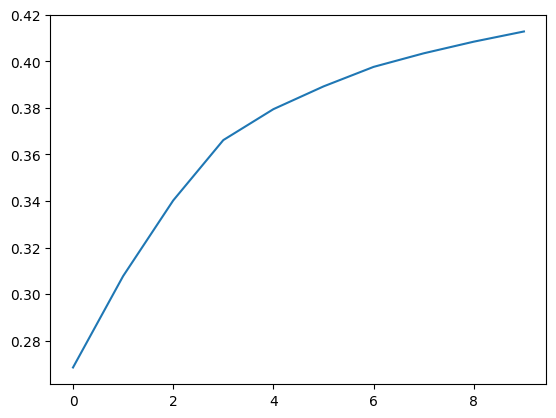

In [22]:
plt.plot(np.cumsum(ipca_obj.explained_variance_ratio_))

In [23]:
dataset, loader = imagenet_val_dataloader(paths, cfg.image_size, cfg.batch_size, shuffle=False)

In [24]:
def get_extreme_k(data, k, dim, extreme):
    sorted_indices = np.argsort(data[:, dim])
    if extreme == "top":
        return sorted_indices[-k:][::-1]
    if extreme == "bottom":
        return sorted_indices[:k]
    raise ValueError(f"Unsupported extreme: {extreme}")
# EOF


def denormalize_imagenet(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (image * std + mean).clamp(0, 1)
# EOF


def extract_project_pc_scores(ann, dataset, ipca_obj, layer, sample_n, batch_size, device, seed=100):
    rng = np.random.default_rng(seed)
    viz_indices = rng.choice(len(dataset), size=min(sample_n, len(dataset)), replace=False).tolist()
    viz_dataset = Subset(dataset, viz_indices)
    viz_loader = DataLoader(viz_dataset, batch_size=batch_size, shuffle=False)

    viz_images = []
    viz_scores = []

    ann.create_forward_hook([layer])
    ann.get_model().eval()
    for images, _ in tqdm(viz_loader, desc="Extracting and projecting images"):
        viz_images.append(images.cpu())

        images = images.to(device, non_blocking=True)
        with torch.inference_mode():
            if cfg.pkg == "hf":
                ann.model(pixel_values=images)
            else:
                ann.model(images)

        features = ann.features[layer].detach().float().cpu().numpy()
        scores = ipca_obj.transform(features)
        viz_scores.append(scores)
    
    viz_images = torch.cat(viz_images)
    viz_scores = np.concatenate(viz_scores, axis=0)
    return viz_images, viz_scores
# EOF


def plot_pc_extremes_distinct(viz_images, viz_scores, layer, n_pcs_to_show=6, n_extreme=6, square_size=1.4):
    n_pcs_to_show = min(n_pcs_to_show, viz_scores.shape[1])
    n_cols = n_extreme * 2 + 1
    width_ratios = [1] * n_extreme + [0.35] + [1] * n_extreme
    fig, axes = plt.subplots(
        n_pcs_to_show,
        n_cols,
        figsize=(square_size * (n_extreme * 2 + 0.35), square_size * n_pcs_to_show),
        gridspec_kw=dict(width_ratios=width_ratios, wspace=0, hspace=0.22),
    )
    axes = np.atleast_2d(axes)

    for pc_idx in range(n_pcs_to_show):
        top_indices = get_extreme_k(viz_scores, n_extreme, pc_idx, "top")
        bottom_indices = get_extreme_k(viz_scores, n_extreme, pc_idx, "bottom")
        row_axes = axes[pc_idx]

        row_axes[0].set_ylabel(f"PC {pc_idx + 1}", fontsize=12, rotation=0, labelpad=28, va="center")
        for ax in row_axes:
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

        for col, idx in enumerate(top_indices):
            row_axes[col].imshow(denormalize_imagenet(viz_images[idx]).permute(1, 2, 0))

        separator_ax = row_axes[n_extreme]
        separator_ax.axis("off")

        for col, idx in enumerate(bottom_indices, start=n_extreme + 1):
            row_axes[col].imshow(denormalize_imagenet(viz_images[idx]).permute(1, 2, 0))

    axes[0, n_extreme // 2].set_title("top", fontsize=12, pad=8)
    axes[0, n_extreme + 1 + n_extreme // 2].set_title("bottom", fontsize=12, pad=8)
    fig.suptitle(f"ImageNet extremes projected on {layer}", y=0.995, fontsize=14)
    plt.show()
    return fig
# EOF


viz_images_distinct, viz_scores_distinct = extract_project_pc_scores(
    ann=ann,
    dataset=dataset,
    ipca_obj=ipca_obj,
    layer=cfg.layer_name,
    sample_n=3000,
    batch_size=cfg.batch_size,
    device=device,
    seed=100,
)

Extracting and projecting images:   0%|          | 0/30 [00:00<?, ?it/s]

In [25]:
def extract_project_pc_scores(ann, dataset, ipca_obj, layer, sample_n, batch_size, device, seed=100):
    rng = np.random.default_rng(seed)
    viz_indices = rng.choice(len(dataset), size=min(sample_n, len(dataset)), replace=False).tolist()
    viz_dataset = Subset(dataset, viz_indices)
    viz_loader = DataLoader(viz_dataset, batch_size=batch_size, shuffle=False)

    viz_images = []
    viz_features = []

    ann.create_forward_hook([layer])
    ann.get_model().eval()
    for images, _ in tqdm(viz_loader, desc="Extracting and projecting images"):
        viz_images.append(images.cpu())

        images = images.to(device, non_blocking=True)
        with torch.inference_mode():
            if cfg.pkg == "hf":
                ann.model(pixel_values=images)
            else:
                ann.model(images)

        features = ann.features[layer].detach().float().cpu().numpy()
        viz_features.append(features)

    viz_images = torch.cat(viz_images)
    viz_features = np.concatenate(viz_features, axis=0)
    viz_scores = ipca_obj.transform(viz_features)
    return viz_images, viz_scores
# EOF


def plot_pc_extremes_distinct(viz_images, viz_scores, layer, n_pcs_to_show=6, n_extreme=6, square_size=1.4):
    n_pcs_to_show = min(n_pcs_to_show, viz_scores.shape[1])
    n_cols = n_extreme * 2 + 1
    width_ratios = [1] * n_extreme + [0.35] + [1] * n_extreme
    fig, axes = plt.subplots(
        n_pcs_to_show,
        n_cols,
        figsize=(square_size * (n_extreme * 2 + 0.35), square_size * n_pcs_to_show),
        gridspec_kw=dict(width_ratios=width_ratios, wspace=0, hspace=0.22),
    )
    axes = np.atleast_2d(axes)

    for pc_idx in range(n_pcs_to_show):
        top_indices = get_extreme_k(viz_scores, n_extreme, pc_idx, "top")
        bottom_indices = get_extreme_k(viz_scores, n_extreme, pc_idx, "bottom")
        row_axes = axes[pc_idx]

        row_axes[0].set_ylabel(f"PC {pc_idx + 1}", fontsize=12, rotation=0, labelpad=28, va="center")
        for ax in row_axes:
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

        for col, idx in enumerate(top_indices):
            row_axes[col].imshow(denormalize_imagenet(viz_images[idx]).permute(1, 2, 0))

        separator_ax = row_axes[n_extreme]
        separator_ax.axis("off")

        for col, idx in enumerate(bottom_indices, start=n_extreme + 1):
            row_axes[col].imshow(denormalize_imagenet(viz_images[idx]).permute(1, 2, 0))

    axes[0, n_extreme // 2].set_title("top", fontsize=12, pad=8)
    axes[0, n_extreme + 1 + n_extreme // 2].set_title("bottom", fontsize=12, pad=8)
    fig.suptitle(f"ImageNet extremes projected on {layer}", y=0.995, fontsize=14)
    plt.show()
    return fig
# EOF

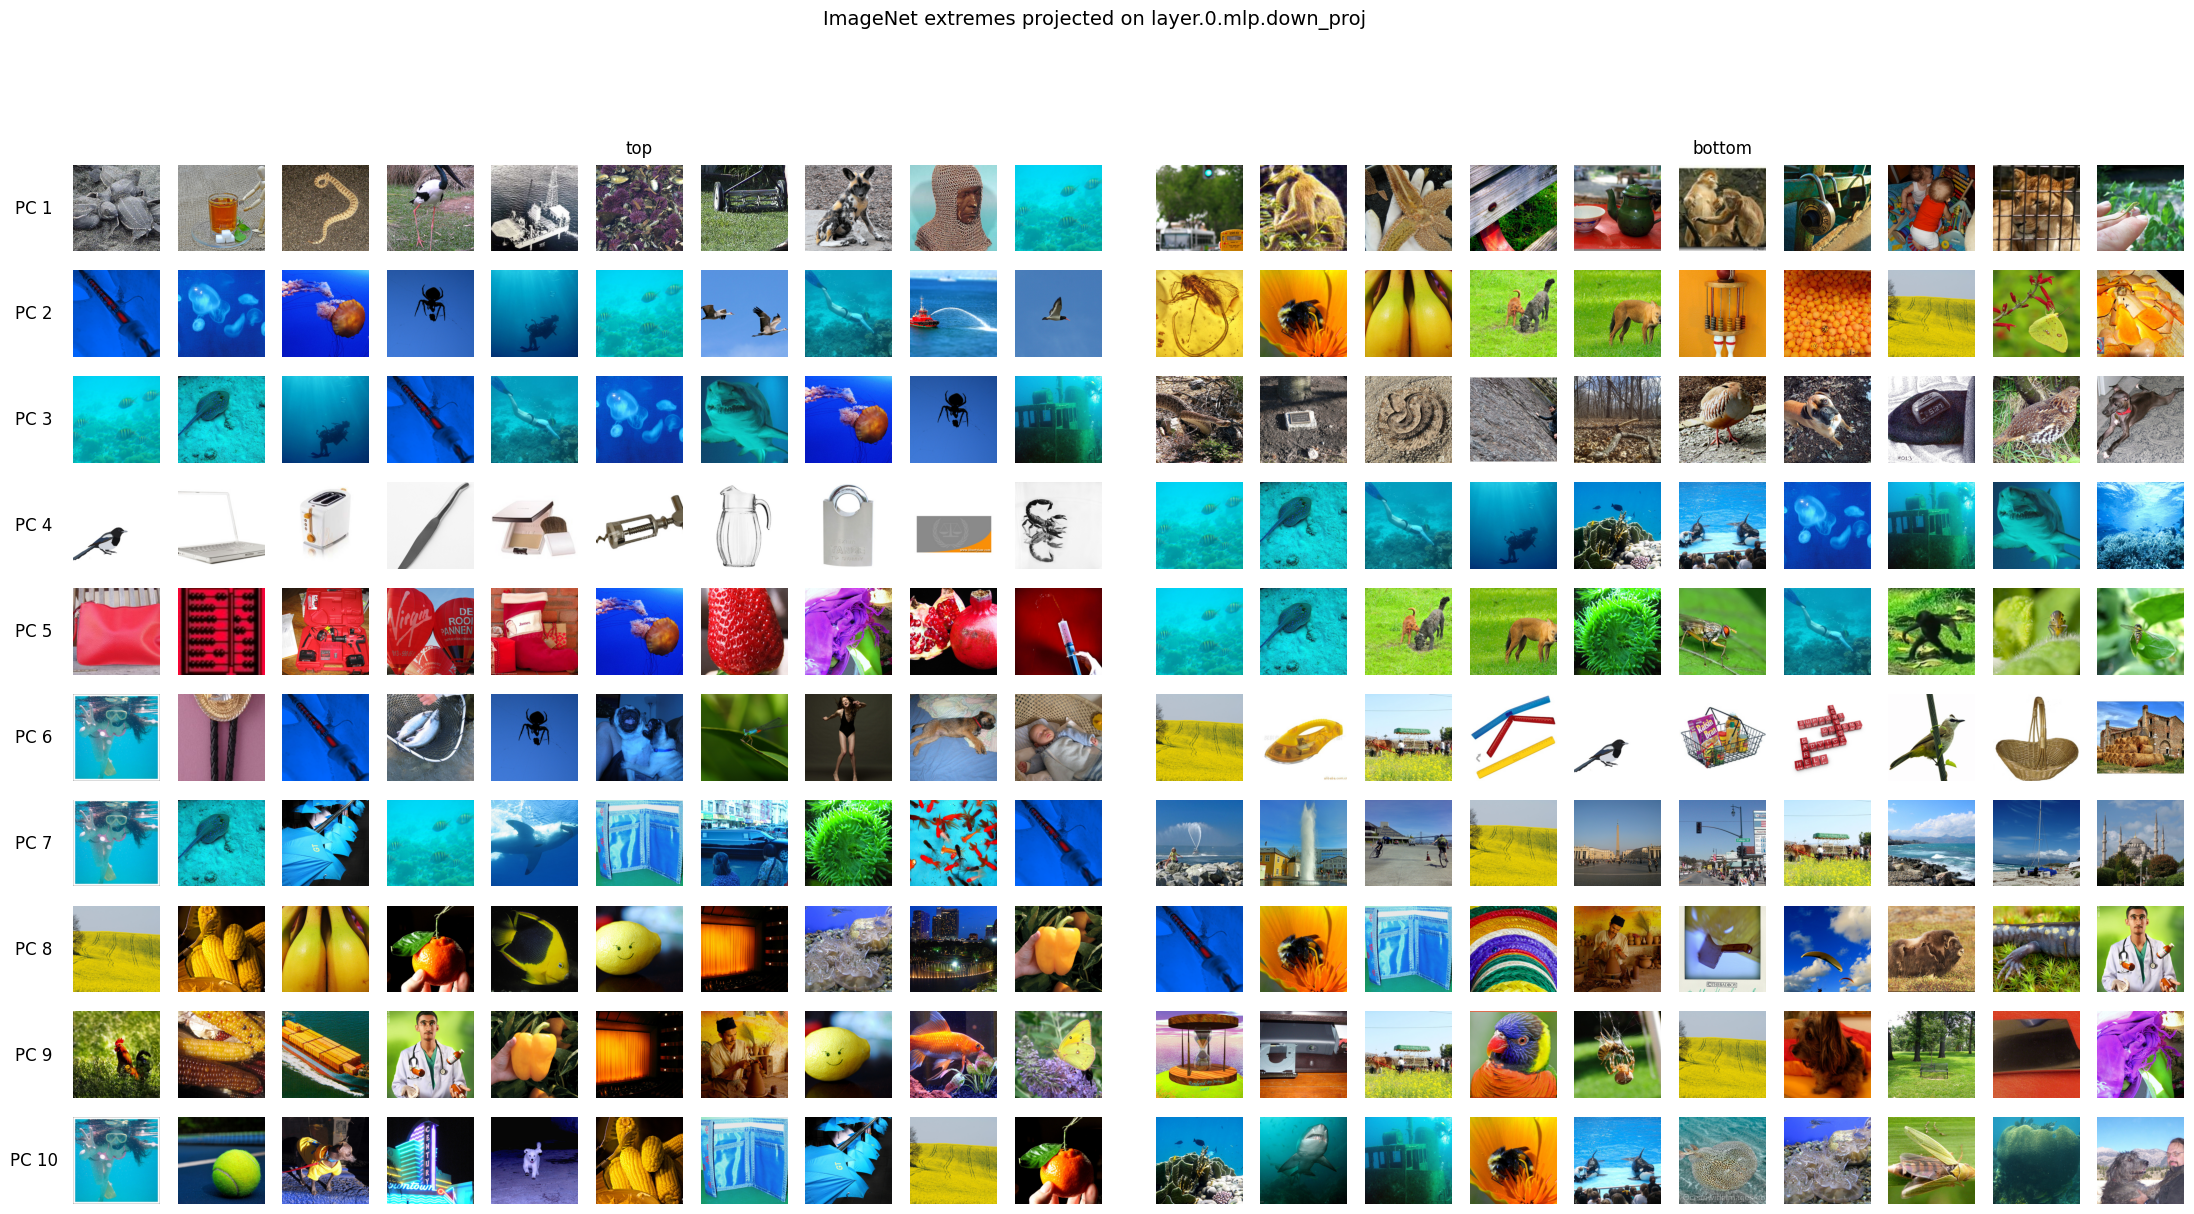

In [26]:
fig = plot_pc_extremes_distinct(
    viz_images=viz_images_distinct,
    viz_scores=viz_scores_distinct,
    layer=cfg.layer_name,
    n_pcs_to_show=10,
    n_extreme=10,
    square_size=1.35,
)

In [27]:
import os
os.system('afplay /System/Library/Sounds/Ping.aiff')

0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..1.4782944].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606442..2.3410363].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping inp

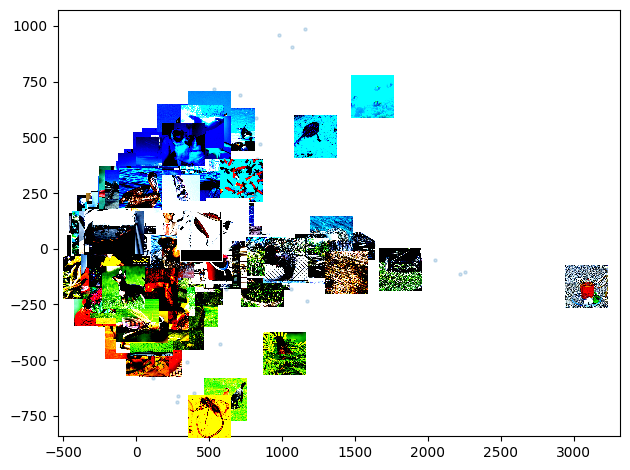

In [28]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots()
pts = viz_scores_distinct[:, :].T
ax.scatter(pts[0, :], pts[1, :], s=5, alpha=0.2)

n = viz_images_distinct.shape[0]
for t in range(n-2000):
    img = viz_images_distinct[t, ...]
    img = img.permute(1,2,0)
    ab = AnnotationBbox(
        OffsetImage(img, zoom=0.08, alpha=1),
        (pts[0, t], pts[1, t]),
        frameon=False,
        # pad=0,
        # bboxprops=dict(
        #     edgecolor='black',
        #     linewidth=1
        # )
    )
    # ab.patch.set_edgecolor('black')
    # ab.patch.set_linewidth(0.5)
    ax.add_artist(ab)

# ax[idx].set_title(f"layer {idx_l}")
# ax[idx].set_xlabel("PC1")
# ax[idx].set_ylabel("PC2")

plt.tight_layout()

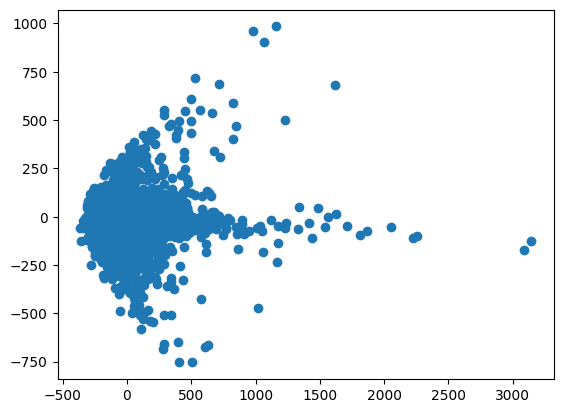

In [29]:
plt.scatter(viz_scores_distinct[:, 0], viz_scores_distinct[:, 1])

In [32]:
loader.batch_size

100

In [34]:
ann.create_forward_hook(layer_names=["layer.0.mlp.down_proj",])

({},
 {'layer.0.mlp.down_proj': <torch.utils.hooks.RemovableHandle at 0x11a8203e0>})

In [38]:
ann.handles.keys()

dict_keys(['layer.0.mlp.down_proj'])